# 02 — EDA（逐季 Statcast 面板）

資料來源：`data/raw/batting_by_season_2018_2024.parquet`（由 01 產生）。

Task：季別分布、PA 門檻、`projection_panel` 所用比率之相關性。


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'DejaVu Sans']
%matplotlib inline

RAW_DIR  = Path('../data/raw')
PROC_DIR = Path('../data/processed')
FIG_DIR  = Path('../figures')
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(RAW_DIR / 'batting_by_season_2018_2024.parquet')

print('資料形狀：', df.shape)
print('\n季別：', sorted(df['season'].unique()))
print('\n欄位型別：')
print(df.info())
print('\n缺失值（age_bat_median 可能缺）：')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n數值統計：')
print(df.describe())


In [ ]:
df = pd.read_csv(RAW_DIR / 'batting_stats_2018_2024.csv')

print('資料形狀：', df.shape)
print('\n欄位型別：')
print(df.info())
print('\n缺失值統計：')
missing = df.isnull().sum()
print(missing[missing > 0])
print('\n數值統計：')
print(df.describe())

資料形狀： (958, 24)

欄位型別：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    958 non-null    object 
 1   Team    958 non-null    object 
 2   G       958 non-null    int64  
 3   PA      958 non-null    int64  
 4   AB      958 non-null    int64  
 5   H       958 non-null    int64  
 6   2B      958 non-null    int64  
 7   3B      958 non-null    int64  
 8   HR      958 non-null    int64  
 9   BB      958 non-null    int64  
 10  K       958 non-null    int64  
 11  HBP     958 non-null    int64  
 12  SF      958 non-null    int64  
 13  AVG     958 non-null    float64
 14  OBP     958 non-null    float64
 15  SLG     958 non-null    float64
 16  OPS     958 non-null    float64
 17  ISO     958 non-null    float64
 18  BABIP   958 non-null    float64
 19  BB%     958 non-null    float64
 20  K%      958 non-null    float64
 21  wOBA    958 non-

## 2-2  主要指標分布圖

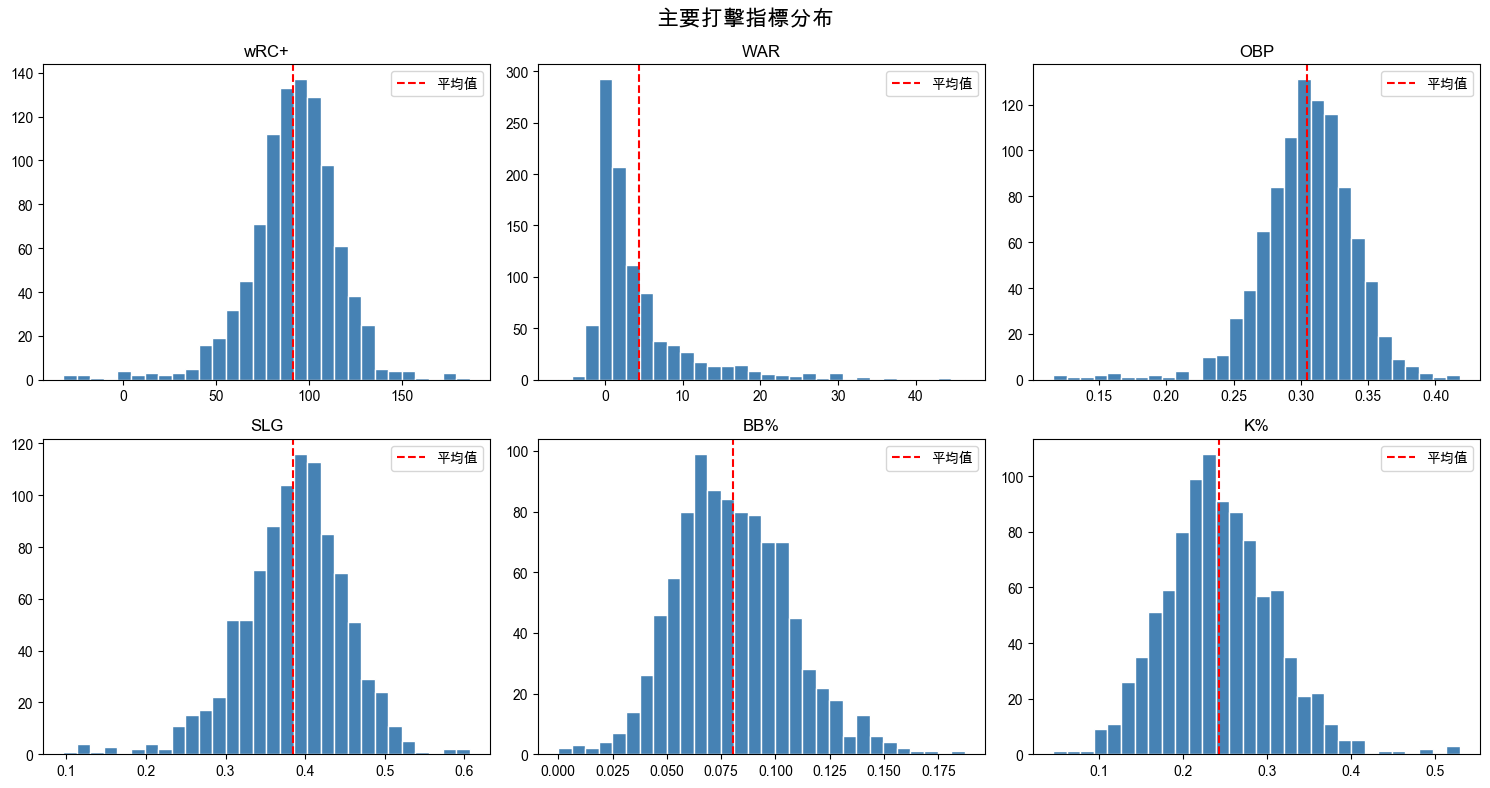

eda_distributions.png 已儲存


In [3]:
metrics = ['wRC+', 'WAR', 'OBP', 'SLG', 'BB%', 'K%']
# Keep only metrics that exist in the dataframe
metrics = [m for m in metrics if m in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('主要打擊指標分布', fontsize=16)

for ax, col in zip(axes.flatten(), metrics):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label='平均值')
    ax.set_title(col)
    ax.legend()

# Hide unused subplots
for ax in axes.flatten()[len(metrics):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('eda_distributions.png 已儲存')

## 2-3  相關係數熱圖

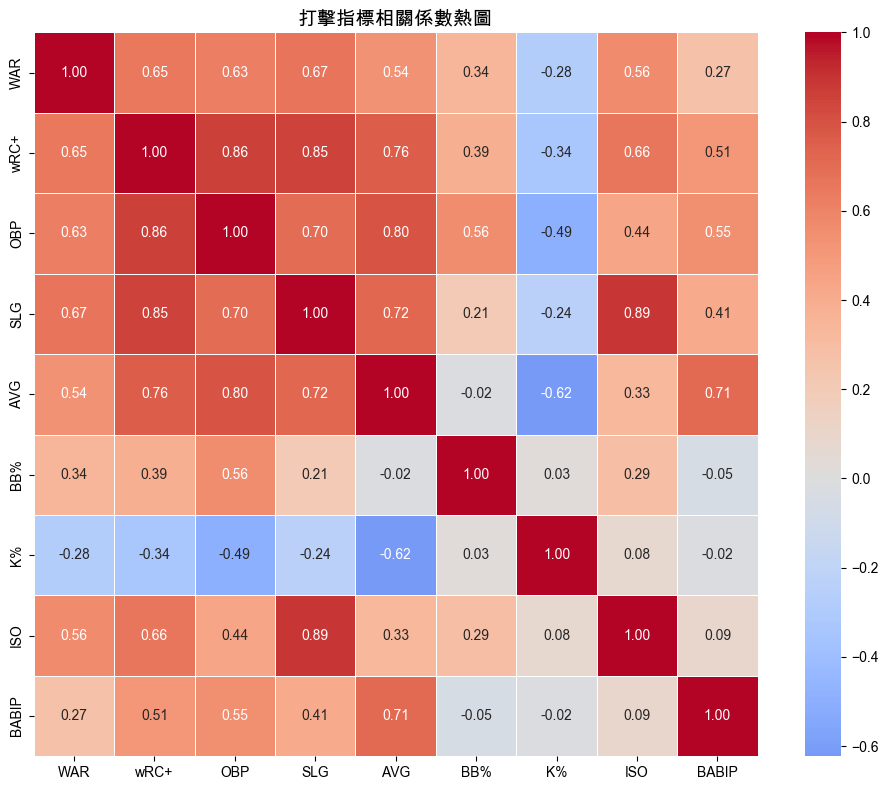

eda_correlation.png 已儲存


In [4]:
cols = ['WAR', 'wRC+', 'OBP', 'SLG', 'AVG', 'BB%', 'K%', 'ISO', 'BABIP']
cols = [c for c in cols if c in df.columns]
corr = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('打擊指標相關係數熱圖', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('eda_correlation.png 已儲存')

## 2-4  wRC+ 前 20 名球員

In [5]:
show_cols = ['Name', 'Team', 'PA', 'AVG', 'OBP', 'wRC+', 'WAR']
show_cols = [c for c in show_cols if c in df.columns]
top20 = df.nlargest(20, 'wRC+')[show_cols]
print(top20.to_string(index=False))

            Name Team   PA   AVG   OBP  wRC+  WAR
    Nathan Lukes  TOR  159 0.286 0.363 186.1  2.3
     Max Schrock  CIN  221 0.306 0.344 173.5  2.8
      Mike Trout  LAA 2639 0.287 0.410 172.8 33.2
     Aaron Judge  NYY 3710 0.291 0.406 172.1 46.3
  Yordan Álvarez  HOU 2800 0.296 0.388 157.4 29.8
       Juan Soto  WSH 4205 0.282 0.418 155.4 43.6
     Darick Hall  PHI  258 0.245 0.295 154.8  2.7
   Shohei Ohtani  LAA 3624 0.282 0.372 152.8 36.4
    Bryce Harper  PHI 3936 0.284 0.396 151.4 38.8
 Freddie Freeman  ATL 4607 0.308 0.396 149.4 44.3
    César Puello  MIA  191 0.245 0.349 149.4  1.8
    Mookie Betts  LAD 4122 0.292 0.381 144.8 37.2
    Ronald Acuña  ATL 3415 0.287 0.378 143.4 30.2
Christian Yelich  MIL 3697 0.284 0.384 138.1 30.2
      Edwin Ríos  LAD  410 0.211 0.302 136.8  3.3
  Anthony Rendon  WSH 2448 0.287 0.378 136.1 19.4
  Fernando Tatís   SD 2299 0.280 0.351 136.1 18.2
    Mark Mathias  PIT  232 0.241 0.328 135.4  1.8
    David Freese  PIT  517 0.305 0.375 134.8  4.0


---
## 3-1  過濾與清理

In [6]:
# 過濾打席不足的球員（提高可信度）
df_clean = df[df['PA'] >= 150].copy()
key_cols = ['wRC+', 'WAR', 'OBP', 'SLG', 'BB%', 'K%']
key_cols = [c for c in key_cols if c in df_clean.columns]
df_clean = df_clean.dropna(subset=key_cols)
print(f'清理後剩餘：{len(df_clean)} 筆')

清理後剩餘：958 筆


## 3-2  建立新特徵

In [7]:
# 孤立長打率：純長打能力
if 'ISO' not in df_clean.columns:
    df_clean['ISO'] = df_clean['SLG'] - df_clean['AVG']

# 三振四壞比：越低越好
df_clean['K_BB_ratio'] = df_clean['K%'] / df_clean['BB%']

# 接觸率
df_clean['contact_rate'] = 1 - df_clean['K%']

# 標準化（用於雷達圖）
radar_features = ['AVG', 'OBP', 'SLG', 'BB%', 'contact_rate', 'ISO']
radar_features = [f for f in radar_features if f in df_clean.columns]
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean[radar_features]),
    columns=radar_features,
    index=df_clean.index
)
print('新特徵建立完成：', ['K_BB_ratio', 'contact_rate', 'ISO'])

新特徵建立完成： ['K_BB_ratio', 'contact_rate', 'ISO']


## 3-3  儲存清理後資料

In [8]:
df_clean.to_csv(PROC_DIR / 'batting_clean.csv', index=False)
df_scaled.to_csv(PROC_DIR / 'batting_scaled.csv', index=False)
print(f'batting_clean.csv  → {len(df_clean)} 筆')
print(f'batting_scaled.csv → {len(df_scaled)} 筆')
print('清理後資料已儲存')

batting_clean.csv  → 958 筆
batting_scaled.csv → 958 筆
清理後資料已儲存
